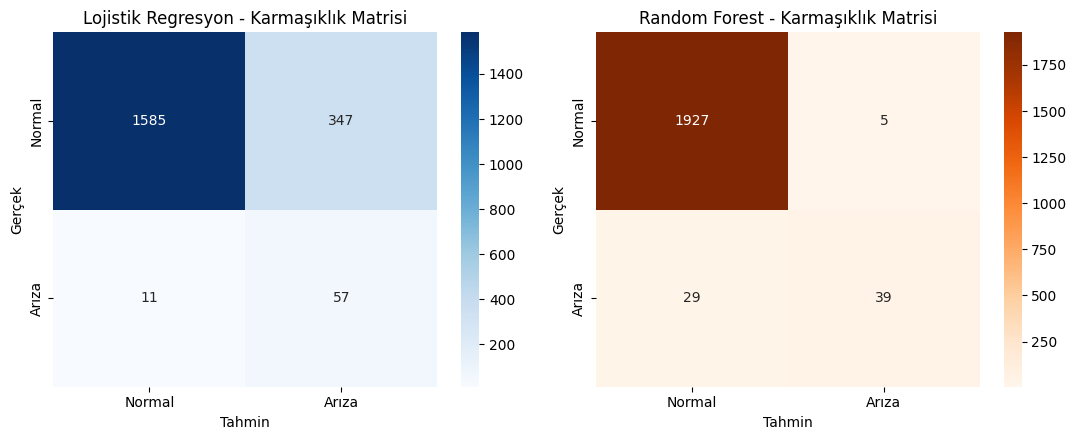

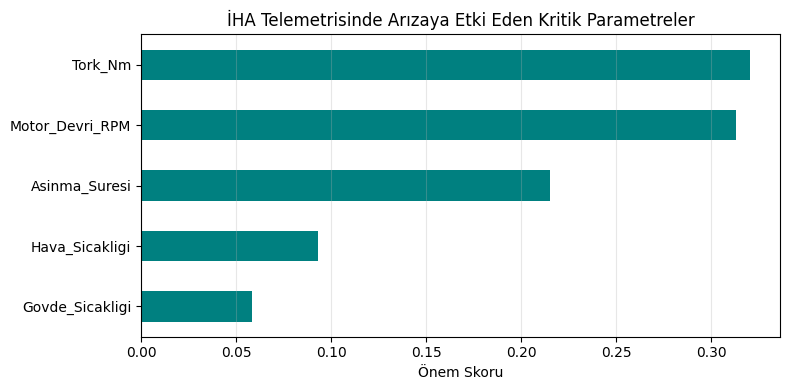

In [2]:
!pip install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. UCI Resmi Kütüphanesinden AI4I Telemetri/Sensör Verisini Çekme (ID: 601)
ai4i_2020_predictive_maintenance_dataset = fetch_ucirepo(id=601)
X = ai4i_2020_predictive_maintenance_dataset.data.features
y = ai4i_2020_predictive_maintenance_dataset.data.targets['Machine failure']

# 2. İlgili Sensör/Telemetri Özniteliklerini Seçme
features = ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']
X = X[features].copy()
X.columns = ['Hava_Sicakligi', 'Govde_Sicakligi', 'Motor_Devri_RPM', 'Tork_Nm', 'Asinma_Suresi']

# 3. Train - Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Modelleri Eğitme
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# 5. Görsel 1: Karmaşıklık Matrisi (Confusion Matrix)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.heatmap(confusion_matrix(y_test, log_reg.predict(X_test_scaled)), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Arıza'], yticklabels=['Normal', 'Arıza'])
axes[0].set_title('Lojistik Regresyon - Karmaşıklık Matrisi')
axes[0].set_xlabel('Tahmin')
axes[0].set_ylabel('Gerçek')

sns.heatmap(confusion_matrix(y_test, rf_model.predict(X_test)), annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Normal', 'Arıza'], yticklabels=['Normal', 'Arıza'])
axes[1].set_title('Random Forest - Karmaşıklık Matrisi')
axes[1].set_xlabel('Tahmin')
axes[1].set_ylabel('Gerçek')

plt.tight_layout()
plt.savefig("sensor_confusion_matrices.png", dpi=300)
plt.show()

# 6. Görsel 2: Öznitelik Önemi (Feature Importance)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='#008080')
plt.title('İHA Telemetrisinde Arızaya Etki Eden Kritik Parametreler')
plt.xlabel('Önem Skoru')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()